# 🚦 Traffic Sign Recognition using Deep Learning
### German Traffic Sign Recognition Benchmark (GTSRB)

---

This notebook covers:
1. Installing & Importing Libraries
2. Loading the GTSRB Dataset
3. Exploring & Visualizing the Data
4. Preprocessing & Data Augmentation
5. Train/Validation/Test Split
6. Custom CNN — Architecture + Training
7. Transfer Learning — ResNet50
8. Transfer Learning — EfficientNet-B0
9. Comparing All Models
10. 3D Architecture Visualizations

---
> **📌 Note:** Make sure you enable **GPU** in Colab: `Runtime → Change runtime type → T4 GPU`

> **🎓 Beginner Tip:** Each section has simple explanations of what we're doing and why!

## 📦 Step 1: Install & Import Libraries

> **What is this?** We first load all the tools we need — like opening a toolbox before starting work.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import seaborn as sns
import os
import time
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50, EfficientNetB0
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

print("✅ TensorFlow version:", tf.__version__)
print("✅ GPU Available:", tf.config.list_physical_devices('GPU'))

✅ TensorFlow version: 2.21.0
✅ GPU Available: []


## 📥 Step 2: Download the GTSRB Dataset

> **What is GTSRB?** It contains **43 types** of German traffic signs — like stop signs, speed limits, etc. We have ~39,000 training images and ~12,600 test images.

In [3]:
import kagglehub
import pandas as pd
from PIL import Image

print("📥 Downloading GTSRB dataset from Kaggle...")
path = kagglehub.dataset_download("meowmeowmeowmeowmeow/gtsrb-german-traffic-sign")
print(f"✅ Dataset downloaded to: {path}")

print("\n📂 Dataset contents:")
for item in sorted(os.listdir(path)):
    print(f"   {item}")

📥 Downloading GTSRB dataset from Kaggle...
✅ Dataset downloaded to: C:\Users\Admin\.cache\kagglehub\datasets\meowmeowmeowmeowmeow\gtsrb-german-traffic-sign\versions\1

📂 Dataset contents:
   Meta
   Meta.csv
   Test
   Test.csv
   Train
   Train.csv


In [4]:
TRAIN_DIR = os.path.join(path, 'Train')
TEST_CSV  = os.path.join(path, 'Test.csv')
TEST_DIR  = os.path.join(path, 'Test')
NUM_CLASSES = 43

def load_train_data(train_dir):
    images, labels = [], []
    class_ids = sorted(os.listdir(train_dir))
    for class_id in class_ids:
        class_path = os.path.join(train_dir, class_id)
        if not os.path.isdir(class_path):
            continue
        for img_file in os.listdir(class_path):
            if img_file.lower().endswith(('.png', '.jpg', '.jpeg', '.ppm')):
                img_path = os.path.join(class_path, img_file)
                img = Image.open(img_path).convert('RGB')
                images.append(np.array(img))
                labels.append(int(class_id))
    return images, np.array(labels)

def load_test_data(test_csv, test_dir):
    df = pd.read_csv(test_csv)
    images, labels = [], []
    for _, row in df.iterrows():
        img_path = os.path.join(path, row['Path'])
        img = Image.open(img_path).convert('RGB')
        images.append(np.array(img))
        labels.append(int(row['ClassId']))
    return images, np.array(labels)

print("🔄 Loading training images... (this may take ~1-2 minutes)")
train_images_raw, train_labels = load_train_data(TRAIN_DIR)
print(f"   ✅ Loaded {len(train_images_raw)} training images")

print("🔄 Loading test images...")
test_images_raw, test_labels = load_test_data(TEST_CSV, TEST_DIR)
print(f"   ✅ Loaded {len(test_images_raw)} test images")

print(f"\n📊 Number of classes : {NUM_CLASSES}")
print(f"🚂 Training samples  : {len(train_images_raw)}")
print(f"🧪 Test samples      : {len(test_images_raw)}")

🔄 Loading training images... (this may take ~1-2 minutes)
   ✅ Loaded 39209 training images
🔄 Loading test images...
   ✅ Loaded 12630 test images

📊 Number of classes : 43
🚂 Training samples  : 39209
🧪 Test samples      : 12630


## ⚙️ Step 3: Configuration

> **Beginner Tip:** These are the settings we use. `IMG_SIZE=32` means each image is resized to 32×32 pixels. `BATCH_SIZE=64` means we train 64 images at a time.

In [5]:
# ─── Image sizes per model ───────────────────────────────────────────────────
IMG_SIZE       = 32    # Custom CNN  — smaller = faster training
RESNET_SIZE    = 64    # ResNet50    — needs more detail
EFFICIENT_SIZE = 64    # EfficientNet-B0

# ─── Training settings ───────────────────────────────────────────────────────
BATCH_SIZE     = 64
EPOCHS         = 30    # Maximum epochs — Early Stopping will stop earlier
NUM_CLASSES    = 43

# ─── Learning rates ──────────────────────────────────────────────────────────
CNN_LR         = 1e-3   # Custom CNN starts at 0.001
RESNET_LR      = 5e-4   # ResNet starts lower — it has pre-trained weights
EFFICIENT_LR   = 5e-4   # EfficientNet same

# ─── Class names ─────────────────────────────────────────────────────────────
CLASS_NAMES = [
    'Speed 20', 'Speed 30', 'Speed 50', 'Speed 60', 'Speed 70',
    'Speed 80', 'End Speed 80', 'Speed 100', 'Speed 120', 'No Passing',
    'No Passing >3.5t', 'Right of Way', 'Priority Road', 'Yield', 'Stop',
    'No Vehicles', 'No Vehicles >3.5t', 'No Entry', 'General Caution',
    'Dangerous Curve Left', 'Dangerous Curve Right', 'Double Curve',
    'Bumpy Road', 'Slippery Road', 'Road Narrows', 'Road Work',
    'Traffic Signals', 'Pedestrians', 'Children Crossing',
    'Bicycles Crossing', 'Ice/Snow', 'Wild Animals', 'End Restrictions',
    'Turn Right', 'Turn Left', 'Go Straight', 'Go Straight/Right',
    'Go Straight/Left', 'Keep Right', 'Keep Left', 'Roundabout',
    'End No Passing', 'End No Passing >3.5t'
]

print("✅ Configuration set!")
print(f"   CNN input  : {IMG_SIZE}×{IMG_SIZE}")
print(f"   ResNet input : {RESNET_SIZE}×{RESNET_SIZE}")
print(f"   EfficientNet input : {EFFICIENT_SIZE}×{EFFICIENT_SIZE}")
print(f"   Max epochs  : {EPOCHS} (Early Stopping will kick in earlier)")

✅ Configuration set!
   CNN input  : 32×32
   ResNet input : 64×64
   EfficientNet input : 64×64
   Max epochs  : 30 (Early Stopping will kick in earlier)


## 🔍 Step 4: Explore the Data

> **Why explore?** Before training, we look at the data to understand it — how many images per class, what they look like, etc.

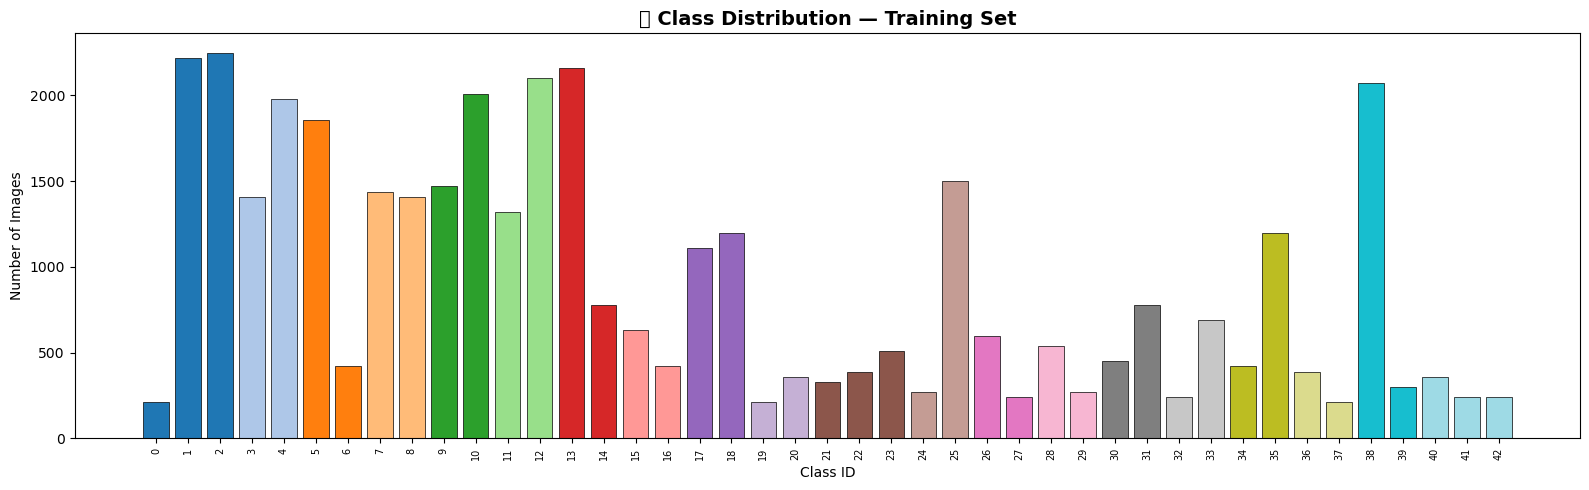

Most common class  : Class 2 — 2250 images
Least common class : Class 0 — 210 images

💡 Notice: Some classes have WAY more images than others.
   This is called 'class imbalance' — it can make the model bias toward common classes.


In [6]:
# ── Class distribution ──────────────────────────────────────────────────────
unique, counts = np.unique(train_labels, return_counts=True)

plt.figure(figsize=(16, 5))
bars = plt.bar(unique, counts, color=plt.cm.tab20(np.linspace(0, 1, NUM_CLASSES)),
               edgecolor='black', linewidth=0.5)
plt.title('📊 Class Distribution — Training Set', fontsize=14, fontweight='bold')
plt.xlabel('Class ID')
plt.ylabel('Number of Images')
plt.xticks(unique, rotation=90, fontsize=7)
plt.tight_layout()
plt.show()

print(f"Most common class  : Class {unique[np.argmax(counts)]} — {counts.max()} images")
print(f"Least common class : Class {unique[np.argmin(counts)]} — {counts.min()} images")
print(f"\n💡 Notice: Some classes have WAY more images than others.")
print("   This is called 'class imbalance' — it can make the model bias toward common classes.")

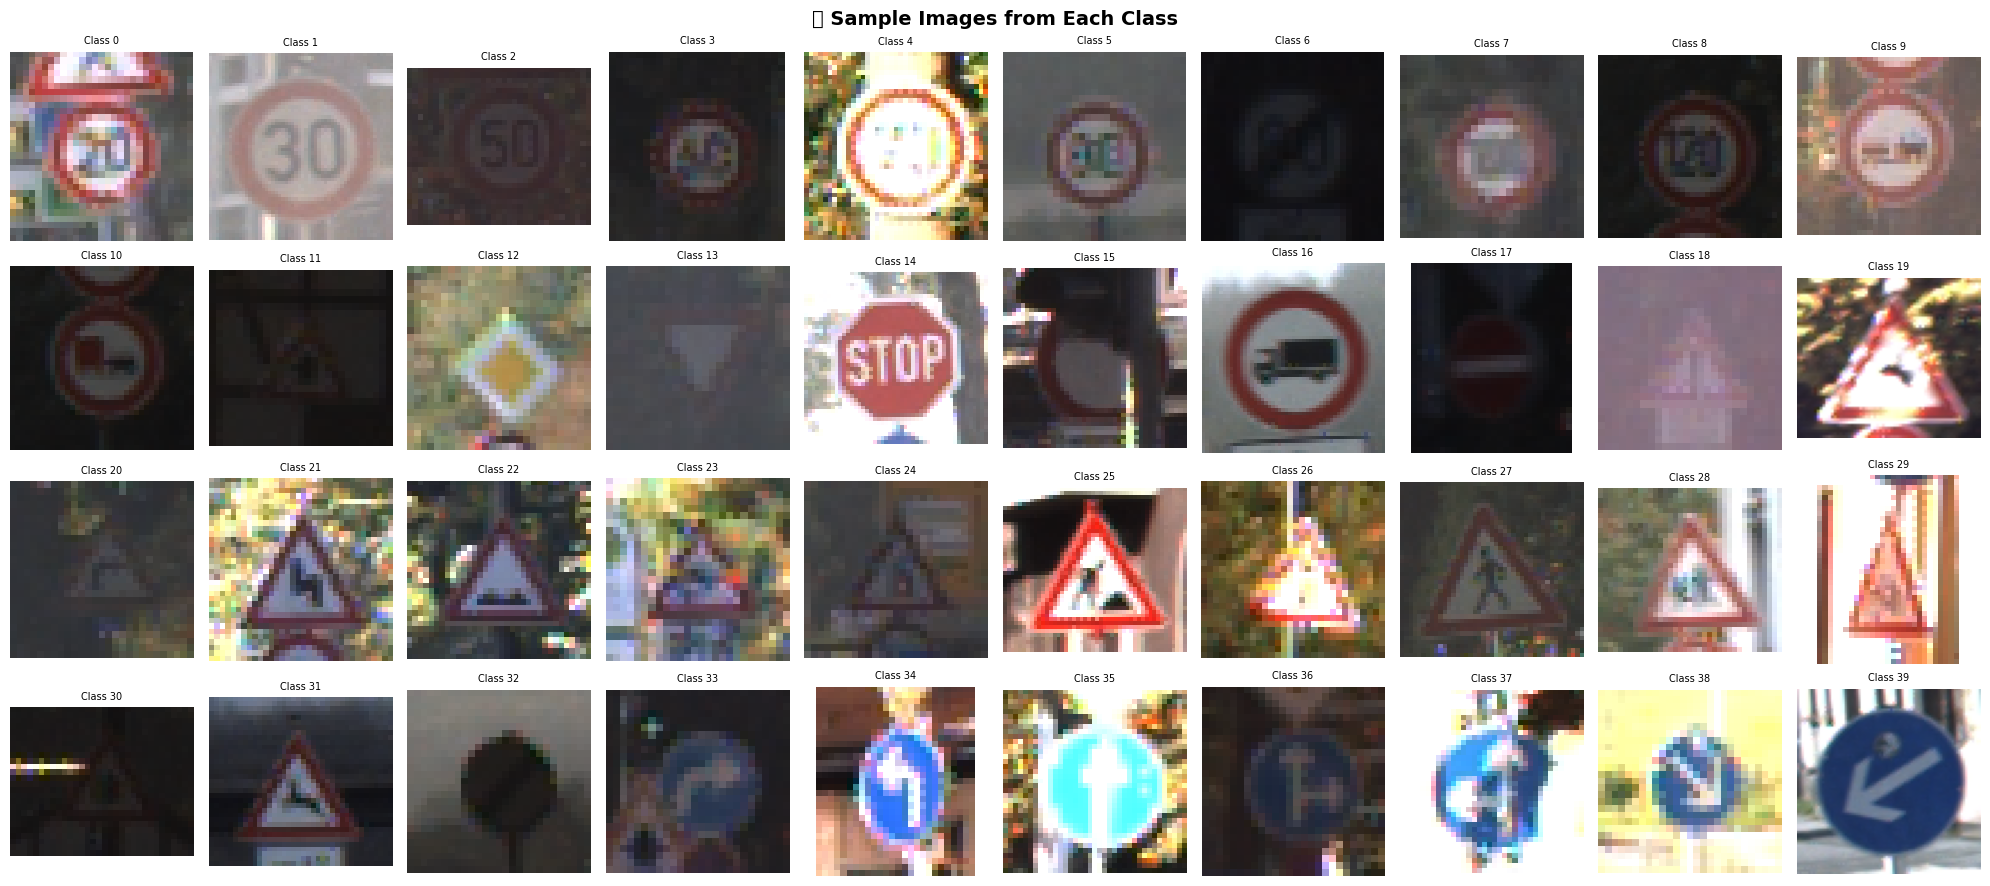

In [7]:
# ── Show sample images ──────────────────────────────────────────────────────
fig, axes = plt.subplots(4, 10, figsize=(20, 9))
fig.suptitle('🖼️ Sample Images from Each Class', fontsize=14, fontweight='bold')

for class_id in range(40):
    # Find first image of this class
    idx = np.where(train_labels == class_id)[0][0]
    row, col = divmod(class_id, 10)
    axes[row, col].imshow(train_images_raw[idx])
    axes[row, col].set_title(f'Class {class_id}', fontsize=7)
    axes[row, col].axis('off')

# Hide the last 2 (we only have 40 subplots for 40 classes shown)
for col in range(0, 10):
    if class_id < col:
        axes[3, col].axis('off')

plt.tight_layout()
plt.show()

## 🔄 Step 5: Preprocessing & Data Augmentation

> **What is preprocessing?** We resize images to a standard size and scale pixel values from [0-255] to [0-1]. This helps the model learn faster.

> **What is augmentation?** We artificially create more training data by slightly rotating, shifting, or zooming images. This helps the model generalize better to new images.

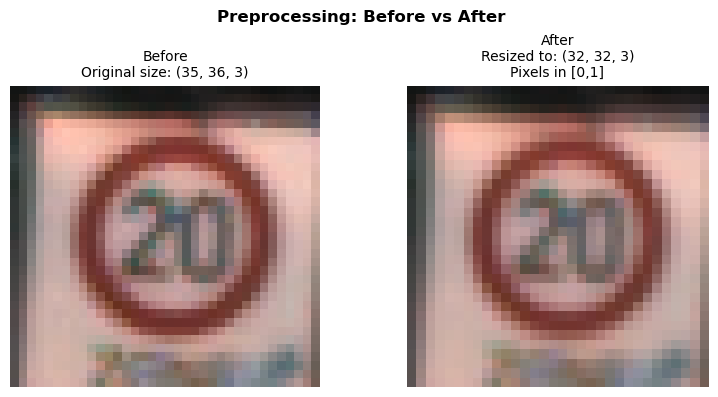

In [8]:
def preprocess_image(img, label):
    """Resize + normalize for Custom CNN (32x32)"""
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32) / 255.0   # scale to [0, 1]
    return img, label

def preprocess_resnet(img, label):
    """Resize + ResNet50 normalization (64x64)"""
    img = tf.image.resize(img, [RESNET_SIZE, RESNET_SIZE])
    img = tf.keras.applications.resnet50.preprocess_input(img)
    return img, label

def preprocess_efficient(img, label):
    """Resize + EfficientNet normalization (64x64)"""
    img = tf.image.resize(img, [EFFICIENT_SIZE, EFFICIENT_SIZE])
    img = tf.keras.applications.efficientnet.preprocess_input(img)
    return img, label

# ── Show Before / After preprocessing ───────────────────────────────────────
sample_idx = 100
raw_img = tf.constant(train_images_raw[sample_idx], dtype=tf.float32)
proc_img, _ = preprocess_image(raw_img, train_labels[sample_idx])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))
fig.suptitle('Preprocessing: Before vs After', fontsize=12, fontweight='bold')

ax1.imshow(train_images_raw[sample_idx])
ax1.set_title(f'Before\nOriginal size: {train_images_raw[sample_idx].shape}', fontsize=10)
ax1.axis('off')

ax2.imshow(proc_img.numpy())
ax2.set_title(f'After\nResized to: {proc_img.shape}\nPixels in [0,1]', fontsize=10)
ax2.axis('off')

plt.tight_layout()
plt.show()

## ✂️ Step 6: Train / Validation / Test Split

> **Why 3 sets?**
> - **Train**: Model learns from this ✏️
> - **Validation**: We check progress during training (model never learns from this) 👀
> - **Test**: Final evaluation AFTER all training is done 🏁

> **Early Stopping** watches the validation loss. If it stops improving for `patience` epochs, training stops automatically. This prevents overfitting!

In [9]:
# ── Convert raw images to arrays ─────────────────────────────────────────────
# We use a fixed size (32x32) for initial splitting, then resize per model
print("🔄 Resizing all images to 32×32 for splitting...")

X_all = np.array([
    np.array(Image.fromarray(img).resize((32, 32)))
    for img in train_images_raw
], dtype=np.uint8)

y_all = train_labels.copy()

# ── Split: 80% train, 10% validation, 10% test-from-train ────────────────────
# We keep the original test set separate (it's already loaded)
X_train, X_val, y_train, y_val = train_test_split(
    X_all, y_all,
    test_size=0.15,          # 15% for validation
    random_state=42,
    stratify=y_all           # keep class distribution balanced
)

# Prepare test set
X_test_raw = test_images_raw
y_test = test_labels

print(f"✅ Train      : {len(X_train):>6} images")
print(f"✅ Validation : {len(X_val):>6} images")
print(f"✅ Test       : {len(X_test_raw):>6} images (original GTSRB test set)")
print(f"\n💡 'stratify=y_all' ensures each class is proportionally represented in all splits.")

🔄 Resizing all images to 32×32 for splitting...
✅ Train      :  33327 images
✅ Validation :   5882 images
✅ Test       :  12630 images (original GTSRB test set)

💡 'stratify=y_all' ensures each class is proportionally represented in all splits.


In [10]:
# ── Helper: build tf.data.Dataset with augmentation ─────────────────────────

def build_dataset(X, y, preproc_fn, augment=False, batch_size=BATCH_SIZE):
    """
    Builds a tf.data.Dataset from numpy arrays.
    Applies preprocessing and optional augmentation.
    """
    ds = tf.data.Dataset.from_tensor_slices(
        (X.astype(np.float32), y.astype(np.int32))
    )

    # Apply model-specific preprocessing
    ds = ds.map(preproc_fn, num_parallel_calls=tf.data.AUTOTUNE)

    # Augmentation only on training data
    if augment:
        def augment_fn(img, label):
            img = tf.image.random_brightness(img, max_delta=0.15)
            img = tf.image.random_contrast(img, 0.85, 1.15)
            img = tf.image.random_crop(img, size=[tf.shape(img)[0], tf.shape(img)[1], 3])
            return img, label

        # Gentle rotation via pad-and-crop
        def pad_crop(img, label):
            h = tf.shape(img)[0]
            w = tf.shape(img)[1]
            img = tf.image.pad_to_bounding_box(img, 2, 2, h+4, w+4)
            img = tf.image.random_crop(img, [h, w, 3])
            return img, label

        ds = ds.map(augment_fn, num_parallel_calls=tf.data.AUTOTUNE)
        ds = ds.map(pad_crop,   num_parallel_calls=tf.data.AUTOTUNE)

    ds = ds.shuffle(2000).batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds


# ── Build test dataset helper ────────────────────────────────────────────────
def build_test_dataset(X_raw, y, target_size, preproc_fn, batch_size=BATCH_SIZE):
    """Resize raw test images to target_size, then apply preprocessing."""
    X_resized = np.array([
        np.array(Image.fromarray(img).resize((target_size, target_size)))
        for img in X_raw
    ], dtype=np.float32)

    ds = tf.data.Dataset.from_tensor_slices(
        (X_resized, y.astype(np.int32))
    )
    ds = ds.map(preproc_fn, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds


# ── Build val dataset at 32x32 for CNN (reuse X_val) ────────────────────────
# We'll build model-specific val datasets inside each model section
print("✅ Dataset builder functions ready!")
print("   Augmentations applied to training only: flip, brightness, contrast, crop")

✅ Dataset builder functions ready!
   Augmentations applied to training only: flip, brightness, contrast, crop


## 🧠 Step 7: Custom CNN Model

> **What is a CNN?** A Convolutional Neural Network is a type of neural network designed for images. It uses 'filters' that slide across the image to detect patterns like edges, shapes, and colors.

> **Architecture:** Input → Conv → Pool → Conv → Pool → Dense → Output

> **Early Stopping:** We use `patience=5` — if validation loss doesn't improve for 5 epochs in a row, training stops.

In [11]:
# ═══════════════════════════════════════════════════════════════════════════
#  Build Custom CNN
# ═══════════════════════════════════════════════════════════════════════════

def build_custom_cnn(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=NUM_CLASSES):
    model = models.Sequential([
        # Block 1
        layers.Input(shape=input_shape),
        layers.Conv2D(32, (3,3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3,3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),

        # Block 2
        layers.Conv2D(64, (3,3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3,3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),

        # Block 3
        layers.Conv2D(128, (3,3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),

        # Classifier head
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ], name='Custom_CNN')
    return model


cnn_model = build_custom_cnn()
cnn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=CNN_LR),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
cnn_model.summary()
cnn_params = cnn_model.count_params()
print(f"\n📊 Total parameters: {cnn_params:,}")

Model: "Custom_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 43)             │        11,051 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 185,803 (725.79 KB)

 Trainable params: 184,651 (721.29 KB)

 Non-trainable params: 1,152 (4.50 KB)


📊 Total parameters: 185,803


In [12]:
# ═══════════════════════════════════════════════════════════════════════════
#  Train Custom CNN with Early Stopping
# ═══════════════════════════════════════════════════════════════════════════

# Build datasets
cnn_train_ds = build_dataset(X_train, y_train, preprocess_image, augment=True)
cnn_val_ds   = build_dataset(X_val,   y_val,   preprocess_image, augment=False)
cnn_test_ds  = build_test_dataset(X_test_raw, y_test, IMG_SIZE, preprocess_image)

# ── Callbacks ───────────────────────────────────────────────────────────────
cnn_callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,                  # stop if no improvement for 5 epochs
        restore_best_weights=True,   # go back to best weights automatically
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,                  # halve the learning rate
        patience=3,                  # after 3 epochs without improvement
        min_lr=1e-6,
        verbose=1
    ),
    ModelCheckpoint(
        'best_cnn.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=0
    )
]

print("🏋️ Training Custom CNN...")
print("   Max epochs: 30 — Early Stopping will stop training earlier if needed")
print("   Watch: val_accuracy should increase gradually. A big gap between")
print("   train_acc and val_acc means overfitting.")
print()

cnn_start = time.time()
cnn_history = cnn_model.fit(
    cnn_train_ds,
    validation_data=cnn_val_ds,
    epochs=EPOCHS,
    callbacks=cnn_callbacks,
    verbose=1
)
cnn_train_time = time.time() - cnn_start

# ── Evaluate ─────────────────────────────────────────────────────────────────
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(cnn_test_ds, verbose=0)

print(f"\n✅ CNN Training complete!")
print(f"   Epochs run      : {len(cnn_history.history['loss'])} (stopped early)")
print(f"   Train time      : {cnn_train_time:.1f}s")
print(f"   Test Accuracy   : {cnn_test_acc*100:.2f}%")
print(f"   Test Loss       : {cnn_test_loss:.4f}")

🏋️ Training Custom CNN...
   Max epochs: 30 — Early Stopping will stop training earlier if needed
   Watch: val_accuracy should increase gradually. A big gap between
   train_acc and val_acc means overfitting.

Epoch 1/30
521/521 ━━━━━━━━━━━━━━━━━━━━ 82s 126ms/step - accuracy: 0.2393 - loss: 2.8708 - val_accuracy: 0.2958 - val_loss: 2.4042 - learning_rate: 0.0010
Epoch 2/30
521/521 ━━━━━━━━━━━━━━━━━━━━ 66s 126ms/step - accuracy: 0.6174 - loss: 1.1780 - val_accuracy: 0.8699 - val_loss: 0.4511 - learning_rate: 0.0010
Epoch 3/30
521/521 ━━━━━━━━━━━━━━━━━━━━ 67s 129ms/step - accuracy: 0.8393 - loss: 0.4902 - val_accuracy: 0.9220 - val_loss: 0.2209 - learning_rate: 0.0010
Epoch 4/30
521/521 ━━━━━━━━━━━━━━━━━━━━ 63s 120ms/step - accuracy: 0.9046 - loss: 0.2909 - val_accuracy: 0.9589 - val_loss: 0.1214 - learning_rate: 0.0010
Epoch 5/30
521/521 ━━━━━━━━━━━━━━━━━━━━ 47s 91ms/step - accuracy: 0.9251 - loss: 0.2229 - val_accuracy: 0.9680 - val_loss: 0.0919 - learning_rate: 0.0010
Epoch 6/30
521/

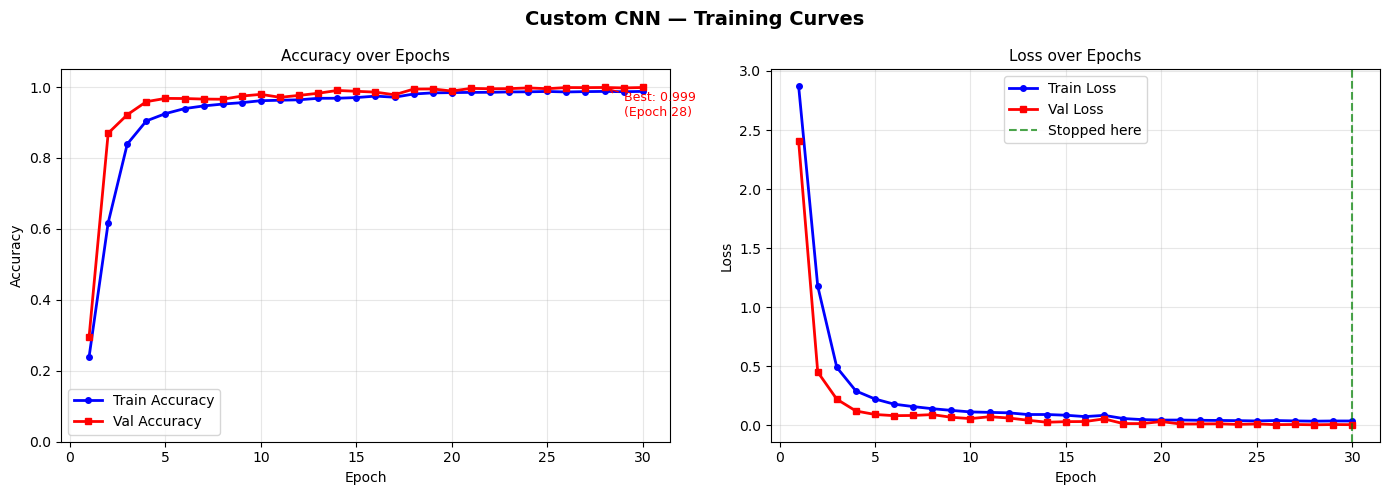

💡 What to look for in these curves:
   ✅ GOOD: Train & Val lines close together — no overfitting
   ✅ GOOD: Val loss decreases then stabilizes
   ⚠️  BAD: Val loss goes UP while train loss goes down = overfitting
   ⚠️  BAD: Both stay high = underfitting


In [14]:
# ═══════════════════════════════════════════════════════════════════════════
#  Plot Training Curves — Custom CNN
#  Good curves: train & val lines close together, val loss decreasing then
#  flattening, no big oscillations
# ═══════════════════════════════════════════════════════════════════════════

epochs_ran = range(1, len(cnn_history.history['loss']) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Custom CNN — Training Curves', fontsize=14, fontweight='bold')

# ── Accuracy ─────────────────────────────────────────────────────────────────
ax1.plot(epochs_ran, cnn_history.history['accuracy'],
         'b-o', markersize=4, linewidth=2, label='Train Accuracy')
ax1.plot(epochs_ran, cnn_history.history['val_accuracy'],
         'r-s', markersize=4, linewidth=2, label='Val Accuracy')
ax1.set_title('Accuracy over Epochs', fontsize=11)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_ylim([0, 1.05])

# Annotate best val accuracy
best_epoch = np.argmax(cnn_history.history['val_accuracy']) + 1
best_val   = max(cnn_history.history['val_accuracy'])
ax1.annotate(f'Best: {best_val:.3f}\n(Epoch {best_epoch})',
             xy=(best_epoch, best_val),
             xytext=(best_epoch + 1, best_val - 0.08),
             arrowprops=dict(arrowstyle='->', color='red'),
             fontsize=9, color='red')

# ── Loss ──────────────────────────────────────────────────────────────────────
ax2.plot(epochs_ran, cnn_history.history['loss'],
         'b-o', markersize=4, linewidth=2, label='Train Loss')
ax2.plot(epochs_ran, cnn_history.history['val_loss'],
         'r-s', markersize=4, linewidth=2, label='Val Loss')
ax2.set_title('Loss over Epochs', fontsize=11)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

# Annotate early stopping point
stopped_epoch = len(epochs_ran)
ax2.axvline(x=stopped_epoch, color='green', linestyle='--', alpha=0.7, label='Stopped here')
ax2.legend(fontsize=10)

plt.tight_layout()
plt.show()

print("💡 What to look for in these curves:")
print("   ✅ GOOD: Train & Val lines close together — no overfitting")
print("   ✅ GOOD: Val loss decreases then stabilizes")
print("   ⚠️  BAD: Val loss goes UP while train loss goes down = overfitting")
print("   ⚠️  BAD: Both stay high = underfitting")

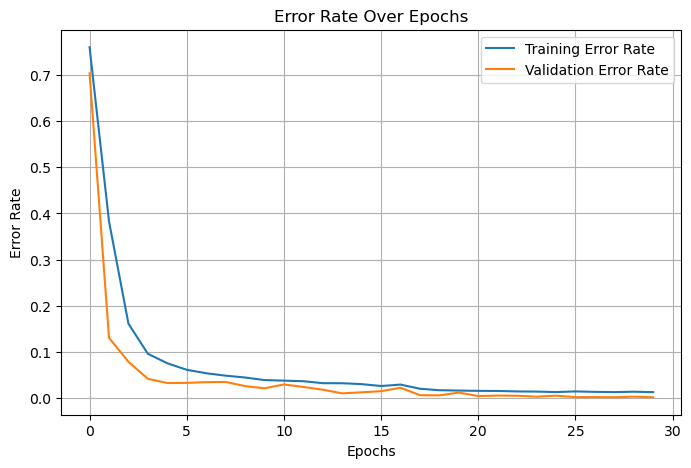

In [18]:
history_df = pd.DataFrame(cnn_history.history)

# حساب error rate
train_error = 1 - history_df['accuracy']
val_error = 1 - history_df['val_accuracy']

plt.figure(figsize=(8,5))
plt.plot(train_error, label='Training Error Rate')
plt.plot(val_error, label='Validation Error Rate')

plt.title('Error Rate Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Error Rate')
plt.legend()
plt.grid(True)
plt.show()

In [20]:
history_df = pd.DataFrame(cnn_history.history)

history_df['train_error'] = 1 - history_df['accuracy']
history_df['val_error'] = 1 - history_df['val_accuracy']

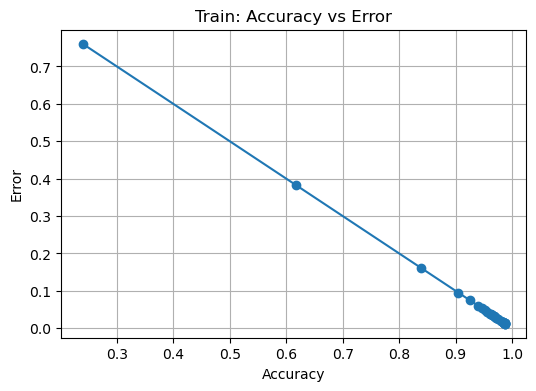

In [21]:
plt.figure(figsize=(6,4))
plt.plot(history_df['accuracy'], history_df['train_error'], 'o-')
plt.xlabel("Accuracy")
plt.ylabel("Error")
plt.title("Train: Accuracy vs Error")
plt.grid(True)
plt.show()

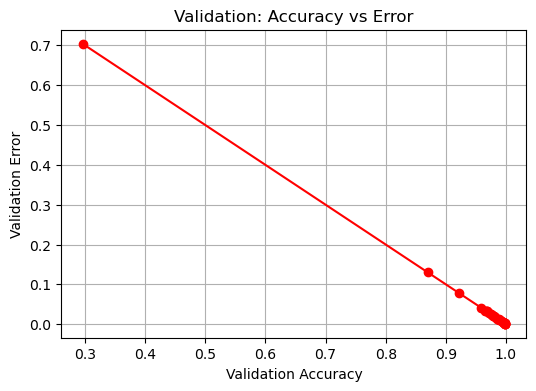

In [22]:
plt.figure(figsize=(6,4))
plt.plot(history_df['val_accuracy'], history_df['val_error'], 'o-', color='red')
plt.xlabel("Validation Accuracy")
plt.ylabel("Validation Error")
plt.title("Validation: Accuracy vs Error")
plt.grid(True)
plt.show()

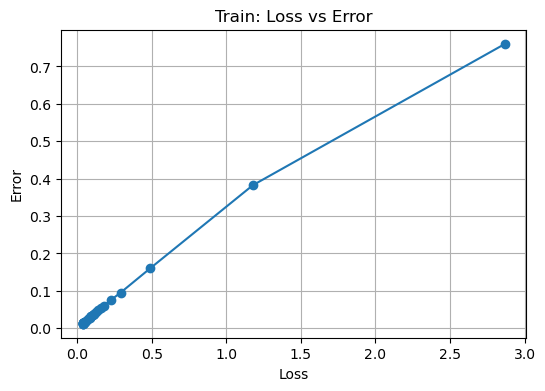

In [23]:
plt.figure(figsize=(6,4))
plt.plot(history_df['loss'], history_df['train_error'], 'o-')
plt.xlabel("Loss")
plt.ylabel("Error")
plt.title("Train: Loss vs Error")
plt.grid(True)
plt.show()

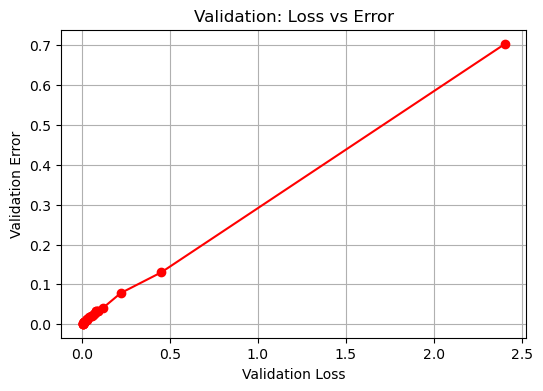

In [24]:
plt.figure(figsize=(6,4))
plt.plot(history_df['val_loss'], history_df['val_error'], 'o-', color='red')
plt.xlabel("Validation Loss")
plt.ylabel("Validation Error")
plt.title("Validation: Loss vs Error")
plt.grid(True)
plt.show()

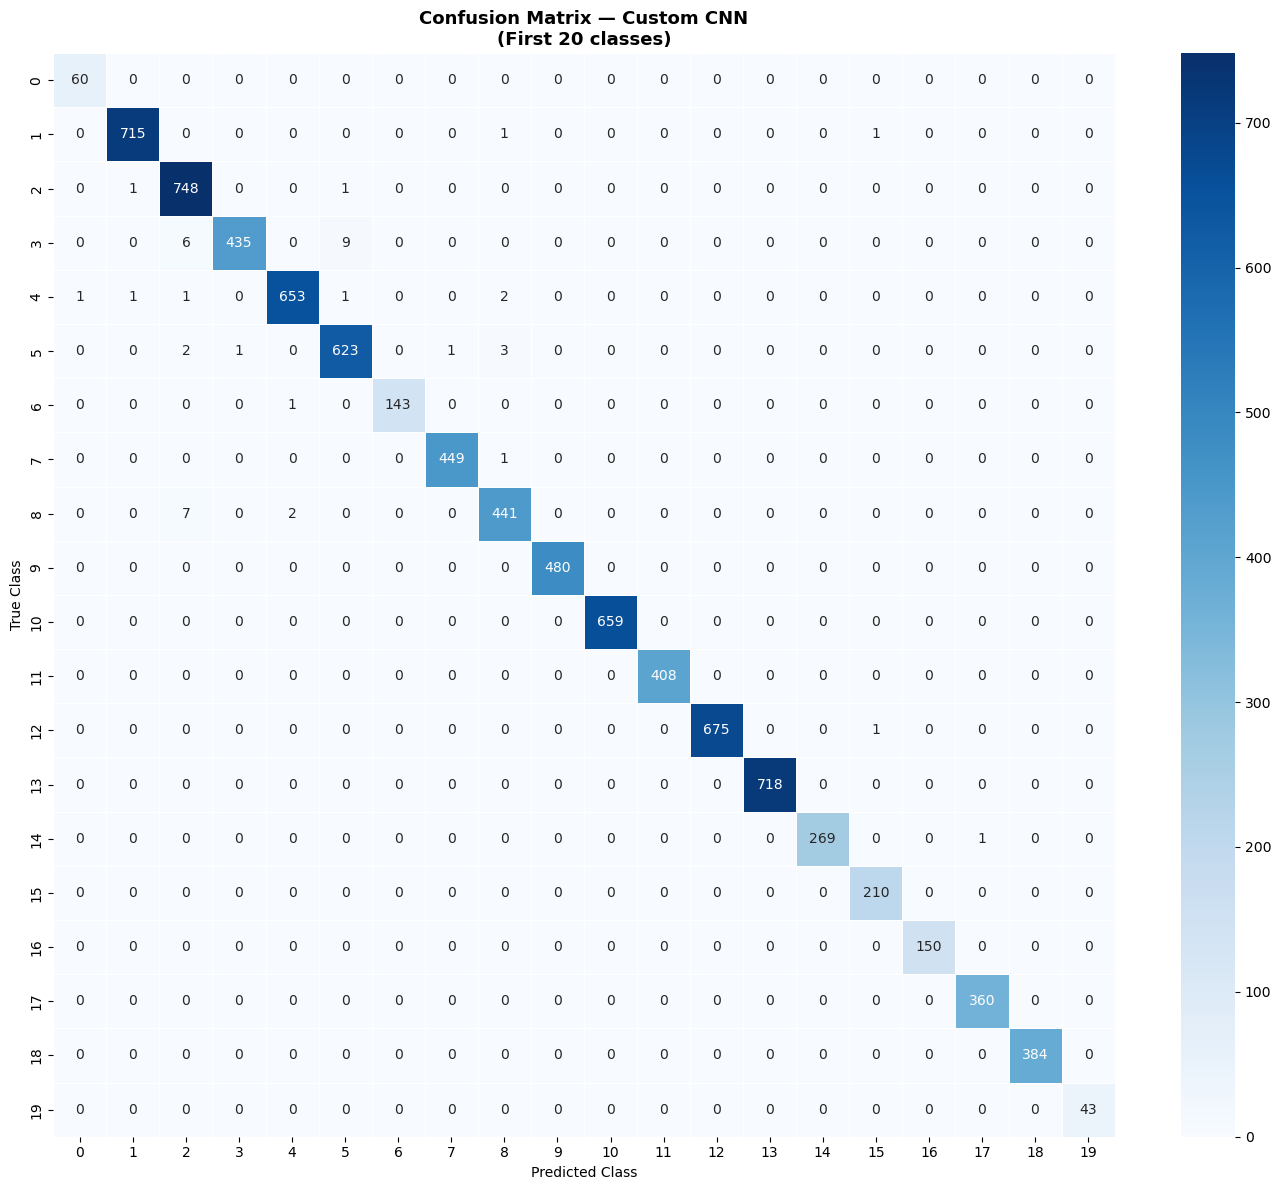


📋 Classification Report — Custom CNN
              precision    recall  f1-score   support

           0       0.98      1.00      0.99        60
           1       1.00      0.99      1.00       720
           2       0.98      1.00      0.99       750
           3       1.00      0.97      0.98       450
           4       1.00      0.99      0.99       660
           5       0.98      0.99      0.99       630
           6       1.00      0.95      0.98       150
           7       1.00      1.00      1.00       450
           8       0.98      0.98      0.98       450
           9       1.00      1.00      1.00       480
          10       1.00      1.00      1.00       660
          11       1.00      0.97      0.99       420
          12       1.00      0.98      0.99       690
          13       1.00      1.00      1.00       720
          14       1.00      1.00      1.00       270
          15       0.99      1.00      1.00       210
          16       1.00      1.00      1.00

In [16]:
# ── Confusion Matrix for CNN ──
def plot_confusion_matrix(model, ds, title, class_names=None, max_classes=20):
    """Plot confusion matrix for the first max_classes classes."""
    y_true, y_pred = [], []
    for images, labels in ds:
        preds = model.predict(images, verbose=0)
        y_pred.extend(np.argmax(preds, axis=1))
        y_true.extend(labels.numpy())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    # Limit to first max_classes for readability
    mask = y_true < max_classes
    cm = confusion_matrix(y_true[mask], y_pred[mask], labels=range(max_classes))

    plt.figure(figsize=(14, 12))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=range(max_classes),
                yticklabels=range(max_classes),
                linewidths=0.5)
    plt.title(f'Confusion Matrix — {title}\n(First {max_classes} classes)', fontsize=13, fontweight='bold')
    plt.xlabel('Predicted Class')
    plt.ylabel('True Class')
    plt.tight_layout()
    plt.show()

    # Classification report
    print(f"\n📋 Classification Report — {title}")
    print(classification_report(y_true, y_pred, zero_division=0))

    return y_true, y_pred

cnn_y_true, cnn_y_pred = plot_confusion_matrix(cnn_model, cnn_test_ds, 'Custom CNN')

## 🔬 Step 8: ResNet50 (Transfer Learning)

> **What is Transfer Learning?** Instead of training from scratch, we use a model (ResNet50) already trained on 1.2 million images (ImageNet). It already knows how to detect edges, textures, and shapes — we just need to teach it to recognize traffic signs specifically.

> **ResNet50** has 50 layers with 'skip connections' — these shortcuts help gradients flow through deep networks without vanishing.

In [28]:
# ═══════════════════════════════════════════════════════════════════════════
#  Build ResNet50 Transfer Learning Model
# ═══════════════════════════════════════════════════════════════════════════

def build_resnet_model(input_shape=(RESNET_SIZE, RESNET_SIZE, 3), num_classes=NUM_CLASSES):
    # Load pre-trained ResNet50 WITHOUT the top classification head
    base = ResNet50(
        include_top=False,
        weights='imagenet',
        input_shape=input_shape
    )

    # Freeze all base layers first — we don't want to corrupt pre-trained weights
    base.trainable = False

    # Build the new model
    inputs  = keras.Input(shape=input_shape)
    x       = base(inputs, training=False)
    x       = layers.GlobalAveragePooling2D()(x)
    x       = layers.Dense(256, activation='relu')(x)
    x       = layers.BatchNormalization()(x)
    x       = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = keras.Model(inputs, outputs, name='ResNet50_Transfer')
    return model, base


resnet_model, resnet_base = build_resnet_model()
resnet_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=RESNET_LR),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

resnet_params = resnet_model.count_params()
trainable     = sum([np.prod(v.shape) for v in resnet_model.trainable_weights])
print(f"📊 Total parameters   : {resnet_params:,}")
print(f"📊 Trainable params   : {trainable:,} (only our new head)")
print(f"📊 Frozen params      : {resnet_params - trainable:,} (ResNet backbone)")

📊 Total parameters   : 24,124,331
📊 Trainable params   : 536,107 (only our new head)
📊 Frozen params      : 23,588,224 (ResNet backbone)


In [29]:
# ── Build ResNet datasets ───────────────────────────────────────────────────
# Need to resize val/train from 32 to 64 for ResNet
X_train_64 = np.array([
    np.array(Image.fromarray(img).resize((RESNET_SIZE, RESNET_SIZE)))
    for img in X_train
], dtype=np.uint8)

X_val_64 = np.array([
    np.array(Image.fromarray(img).resize((RESNET_SIZE, RESNET_SIZE)))
    for img in X_val
], dtype=np.uint8)

resnet_train_ds = build_dataset(X_train_64, y_train, preprocess_resnet, augment=True)
resnet_val_ds   = build_dataset(X_val_64,   y_val,   preprocess_resnet, augment=False)
resnet_test_ds  = build_test_dataset(X_test_raw, y_test, RESNET_SIZE, preprocess_resnet)

# ── Callbacks ───────────────────────────────────────────────────────────────
resnet_callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    ),
    ModelCheckpoint('best_resnet.keras', monitor='val_accuracy',
                    save_best_only=True, verbose=0)
]

print("🏋️ Training ResNet50 (Phase 1: Frozen base)...")
resnet_start = time.time()
resnet_history = resnet_model.fit(
    resnet_train_ds,
    validation_data=resnet_val_ds,
    epochs=EPOCHS,
    callbacks=resnet_callbacks,
    verbose=1
)
resnet_train_time = time.time() - resnet_start

resnet_test_loss, resnet_test_acc = resnet_model.evaluate(resnet_test_ds, verbose=0)

print(f"\n✅ ResNet50 Training complete!")
print(f"   Epochs run    : {len(resnet_history.history['loss'])}")
print(f"   Train time    : {resnet_train_time:.1f}s")
print(f"   Test Accuracy : {resnet_test_acc*100:.2f}%")
print(f"   Test Loss     : {resnet_test_loss:.4f}")

🏋️ Training ResNet50 (Phase 1: Frozen base)...
Epoch 1/30
521/521 ━━━━━━━━━━━━━━━━━━━━ 134s 237ms/step - accuracy: 0.5718 - loss: 1.4482 - val_accuracy: 0.7418 - val_loss: 0.7765 - learning_rate: 5.0000e-04
Epoch 2/30
521/521 ━━━━━━━━━━━━━━━━━━━━ 101s 193ms/step - accuracy: 0.7390 - loss: 0.7999 - val_accuracy: 0.8048 - val_loss: 0.5770 - learning_rate: 5.0000e-04
Epoch 3/30
521/521 ━━━━━━━━━━━━━━━━━━━━ 88s 168ms/step - accuracy: 0.7949 - loss: 0.6216 - val_accuracy: 0.8392 - val_loss: 0.4904 - learning_rate: 5.0000e-04
Epoch 4/30
521/521 ━━━━━━━━━━━━━━━━━━━━ 100s 191ms/step - accuracy: 0.8210 - loss: 0.5324 - val_accuracy: 0.8572 - val_loss: 0.4241 - learning_rate: 5.0000e-04
Epoch 5/30
521/521 ━━━━━━━━━━━━━━━━━━━━ 90s 173ms/step - accuracy: 0.8414 - loss: 0.4750 - val_accuracy: 0.8723 - val_loss: 0.3860 - learning_rate: 5.0000e-04
Epoch 6/30
521/521 ━━━━━━━━━━━━━━━━━━━━ 86s 165ms/step - accuracy: 0.8508 - loss: 0.4380 - val_accuracy: 0.8757 - val_loss: 0.3534 - learning_rate: 5.0000e

In [30]:
# Print layer names with indices to pick your FINE_TUNE_AT value
for i, layer in enumerate(resnet_base.layers):
    print(f"{i:3d}  trainable={layer.trainable}  {layer.name}")

  0  trainable=False  input_layer_1
  1  trainable=False  conv1_pad
  2  trainable=False  conv1_conv
  3  trainable=False  conv1_bn
  4  trainable=False  conv1_relu
  5  trainable=False  pool1_pad
  6  trainable=False  pool1_pool
  7  trainable=False  conv2_block1_1_conv
  8  trainable=False  conv2_block1_1_bn
  9  trainable=False  conv2_block1_1_relu
 10  trainable=False  conv2_block1_2_conv
 11  trainable=False  conv2_block1_2_bn
 12  trainable=False  conv2_block1_2_relu
 13  trainable=False  conv2_block1_0_conv
 14  trainable=False  conv2_block1_3_conv
 15  trainable=False  conv2_block1_0_bn
 16  trainable=False  conv2_block1_3_bn
 17  trainable=False  conv2_block1_add
 18  trainable=False  conv2_block1_out
 19  trainable=False  conv2_block2_1_conv
 20  trainable=False  conv2_block2_1_bn
 21  trainable=False  conv2_block2_1_relu
 22  trainable=False  conv2_block2_2_conv
 23  trainable=False  conv2_block2_2_bn
 24  trainable=False  conv2_block2_2_relu
 25  trainable=False  conv2_bloc

In [31]:
# ── Phase 2: Fine-Tuning ─────────────────────────────────────────────────

# 1. Load the best weights saved from Phase 1
resnet_model.load_weights('best_resnet.keras')

# 2. Unfreeze the base — but only the LAST N layers
resnet_base.trainable = True

FINE_TUNE_AT = 140  # unfreeze from this layer onward (ResNet50 has 175 layers)
for layer in resnet_base.layers[:FINE_TUNE_AT]:
    layer.trainable = False  # keep early layers frozen

# Sanity check
trainable_ft = sum([np.prod(v.shape) for v in resnet_model.trainable_weights])
print(f"📊 Fine-tune trainable params: {trainable_ft:,}")

# 3. Recompile with a MUCH lower learning rate (crucial!)
resnet_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=RESNET_LR / 10),  # e.g. 1e-5
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 4. Fine-tuning callbacks
finetune_callbacks = [
    EarlyStopping(monitor='val_loss', patience=5,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=3, min_lr=1e-8, verbose=1),
    ModelCheckpoint('best_resnet_finetuned.keras',
                    monitor='val_accuracy', save_best_only=True, verbose=0)
]

# 5. Continue training — pass initial_epoch to keep history continuous
print("🔥 Fine-tuning ResNet50 (Phase 2: Partial unfreeze)...")
ft_start = time.time()

total_epochs = EPOCHS + 20  # Phase 1 epochs + fine-tune epochs

finetune_history = resnet_model.fit(
    resnet_train_ds,
    validation_data=resnet_val_ds,
    epochs=total_epochs,
    initial_epoch=len(resnet_history.history['loss']),  # resume from where P1 ended
    callbacks=finetune_callbacks,
    verbose=1
)

ft_time = time.time() - ft_start
ft_loss, ft_acc = resnet_model.evaluate(resnet_test_ds, verbose=0)
print(f"\n✅ Fine-tuning complete!")
print(f"   Train time    : {ft_time:.1f}s")
print(f"   Test Accuracy : {ft_acc*100:.2f}%")
print(f"   Test Loss     : {ft_loss:.4f}")

📊 Fine-tune trainable params: 15,514,155
🔥 Fine-tuning ResNet50 (Phase 2: Partial unfreeze)...
Epoch 31/50
521/521 ━━━━━━━━━━━━━━━━━━━━ 324s 599ms/step - accuracy: 0.8150 - loss: 0.6037 - val_accuracy: 0.9213 - val_loss: 0.2251 - learning_rate: 5.0000e-05
Epoch 32/50
521/521 ━━━━━━━━━━━━━━━━━━━━ 305s 584ms/step - accuracy: 0.9236 - loss: 0.2206 - val_accuracy: 0.9524 - val_loss: 0.1344 - learning_rate: 5.0000e-05
Epoch 33/50
521/521 ━━━━━━━━━━━━━━━━━━━━ 249s 478ms/step - accuracy: 0.9501 - loss: 0.1488 - val_accuracy: 0.9679 - val_loss: 0.0951 - learning_rate: 5.0000e-05
Epoch 34/50
521/521 ━━━━━━━━━━━━━━━━━━━━ 261s 502ms/step - accuracy: 0.9619 - loss: 0.1095 - val_accuracy: 0.9748 - val_loss: 0.0760 - learning_rate: 5.0000e-05
Epoch 35/50
521/521 ━━━━━━━━━━━━━━━━━━━━ 316s 607ms/step - accuracy: 0.9694 - loss: 0.0912 - val_accuracy: 0.9764 - val_loss: 0.0671 - learning_rate: 5.0000e-05
Epoch 36/50
521/521 ━━━━━━━━━━━━━━━━━━━━ 362s 692ms/step - accuracy: 0.9756 - loss: 0.0741 - val_acc

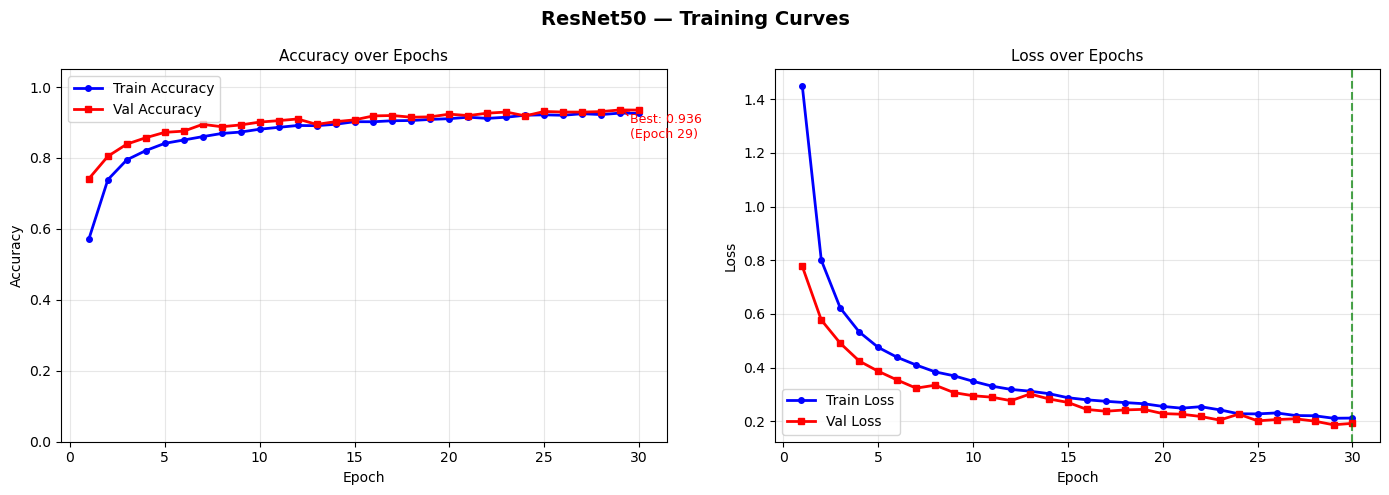

In [33]:
# ── Training Curves — ResNet50 ───────────────────────────────────────────────
epochs_ran_r = range(1, len(resnet_history.history['loss']) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('ResNet50 — Training Curves', fontsize=14, fontweight='bold')

ax1.plot(epochs_ran_r, resnet_history.history['accuracy'],
         'b-o', markersize=4, linewidth=2, label='Train Accuracy')
ax1.plot(epochs_ran_r, resnet_history.history['val_accuracy'],
         'r-s', markersize=4, linewidth=2, label='Val Accuracy')
ax1.set_title('Accuracy over Epochs', fontsize=11)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_ylim([0, 1.05])

best_epoch_r = np.argmax(resnet_history.history['val_accuracy']) + 1
best_val_r   = max(resnet_history.history['val_accuracy'])
ax1.annotate(f'Best: {best_val_r:.3f}\n(Epoch {best_epoch_r})',
             xy=(best_epoch_r, best_val_r),
             xytext=(best_epoch_r + 0.5, best_val_r - 0.08),
             arrowprops=dict(arrowstyle='->', color='red'),
             fontsize=9, color='red')

ax2.plot(epochs_ran_r, resnet_history.history['loss'],
         'b-o', markersize=4, linewidth=2, label='Train Loss')
ax2.plot(epochs_ran_r, resnet_history.history['val_loss'],
         'r-s', markersize=4, linewidth=2, label='Val Loss')
ax2.set_title('Loss over Epochs', fontsize=11)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

ax2.axvline(x=len(epochs_ran_r), color='green', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

## ⚡ Step 9: EfficientNet-B0 (Transfer Learning)

> **What makes EfficientNet special?** It uses 'compound scaling' — it scales width, depth, and resolution together in a balanced way. This gives better accuracy with fewer parameters than ResNet.

> **EfficientNet-B0** is the smallest and fastest in the EfficientNet family.

In [11]:
def build_efficient_model(input_shape=(EFFICIENT_SIZE, EFFICIENT_SIZE, 3), num_classes=NUM_CLASSES):
    base = EfficientNetB0(
        include_top=False,
        weights='imagenet',
        input_shape=input_shape
    )
    base.trainable = False

    inputs  = keras.Input(shape=input_shape)
    x       = base(inputs, training=False)
    x       = layers.GlobalAveragePooling2D()(x)
    x       = layers.Dense(256, activation='relu')(x)
    x       = layers.BatchNormalization()(x)
    x       = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = keras.Model(inputs, outputs, name='EfficientNet_B0_Transfer')
    return model, base


efficient_model, efficient_base = build_efficient_model()
efficient_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=EFFICIENT_LR),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

efficient_params = efficient_model.count_params()
trainable_eff    = sum([np.prod(v.shape) for v in efficient_model.trainable_weights])
print(f"📊 Total parameters : {efficient_params:,}")
print(f"📊 Trainable params : {trainable_eff:,} (only new head)")

📊 Total parameters : 4,389,582
📊 Trainable params : 339,499 (only new head)


In [13]:
eff_callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    ),
    ModelCheckpoint('best_efficientnet.keras', monitor='val_accuracy',
                    save_best_only=True, verbose=0)
]

# Use same 64x64 data as ResNet
eff_callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    ),
    ModelCheckpoint('best_efficientnet.keras', monitor='val_accuracy',
                    save_best_only=True, verbose=0)
]

# Use same 64x64 data as ResNet
X_train_64 = np.array([
    np.array(Image.fromarray(img).resize((RESNET_SIZE, RESNET_SIZE)))
    for img in X_train
], dtype=np.uint8)

X_val_64 = np.array([
    np.array(Image.fromarray(img).resize((RESNET_SIZE, RESNET_SIZE)))
    for img in X_val
], dtype=np.uint8)

eff_train_ds = build_dataset(X_train_64, y_train, preprocess_efficient, augment=True)
eff_val_ds   = build_dataset(X_val_64,   y_val,   preprocess_efficient, augment=False)
eff_test_ds  = build_test_dataset(X_test_raw, y_test, EFFICIENT_SIZE, preprocess_efficient)

print("🏋️ Training EfficientNet-B0...")
eff_start = time.time()
eff_history = efficient_model.fit(
    eff_train_ds,
    validation_data=eff_val_ds,
    epochs=EPOCHS,
    callbacks=eff_callbacks,
    verbose=1
)
eff_train_time = time.time() - eff_start

eff_test_loss, eff_test_acc = efficient_model.evaluate(eff_test_ds, verbose=0)

print(f"\n✅ EfficientNet Training complete!")
print(f"   Epochs run    : {len(eff_history.history['loss'])}")
print(f"   Train time    : {eff_train_time:.1f}s")
print(f"   Test Accuracy : {eff_test_acc*100:.2f}%")
print(f"   Test Loss     : {eff_test_loss:.4f}")
eff_val_ds   = build_dataset(X_val_64,   y_val,   preprocess_efficient, augment=False)
eff_test_ds  = build_test_dataset(X_test_raw, y_test, EFFICIENT_SIZE, preprocess_efficient)

print("🏋️ Training EfficientNet-B0...")
eff_start = time.time()
eff_history = efficient_model.fit(
    eff_train_ds,
    validation_data=eff_val_ds,
    epochs=EPOCHS,
    callbacks=eff_callbacks,
    verbose=1
)
eff_train_time = time.time() - eff_start

eff_test_loss, eff_test_acc = efficient_model.evaluate(eff_test_ds, verbose=0)

print(f"\n✅ EfficientNet Training complete!")
print(f"   Epochs run    : {len(eff_history.history['loss'])}")
print(f"   Train time    : {eff_train_time:.1f}s")
print(f"   Test Accuracy : {eff_test_acc*100:.2f}%")
print(f"   Test Loss     : {eff_test_loss:.4f}")

🏋️ Training EfficientNet-B0...
Epoch 1/30
521/521 ━━━━━━━━━━━━━━━━━━━━ 166s 254ms/step - accuracy: 0.5736 - loss: 1.4394 - val_accuracy: 0.7635 - val_loss: 0.7437 - learning_rate: 5.0000e-04
Epoch 2/30
521/521 ━━━━━━━━━━━━━━━━━━━━ 130s 249ms/step - accuracy: 0.7245 - loss: 0.8352 - val_accuracy: 0.8256 - val_loss: 0.5468 - learning_rate: 5.0000e-04
Epoch 3/30
521/521 ━━━━━━━━━━━━━━━━━━━━ 143s 274ms/step - accuracy: 0.7695 - loss: 0.6863 - val_accuracy: 0.8444 - val_loss: 0.4834 - learning_rate: 5.0000e-04
Epoch 4/30
521/521 ━━━━━━━━━━━━━━━━━━━━ 145s 278ms/step - accuracy: 0.7930 - loss: 0.6116 - val_accuracy: 0.8548 - val_loss: 0.4387 - learning_rate: 5.0000e-04
Epoch 5/30
521/521 ━━━━━━━━━━━━━━━━━━━━ 141s 270ms/step - accuracy: 0.8083 - loss: 0.5674 - val_accuracy: 0.8708 - val_loss: 0.3916 - learning_rate: 5.0000e-04
Epoch 6/30
521/521 ━━━━━━━━━━━━━━━━━━━━ 237s 454ms/step - accuracy: 0.8200 - loss: 0.5306 - val_accuracy: 0.8796 - val_loss: 0.3770 - learning_rate: 5.0000e-04
Epoch 7/3

In [18]:
from sklearn.metrics import classification_report
import numpy as np

# ============================================================
#  Get Predictions
# ============================================================
y_pred_probs = efficient_model.predict(eff_test_ds, verbose=1)

# Convert probabilities → class labels
y_pred = np.argmax(y_pred_probs, axis=1)

# ============================================================
#  Get True Labels
# ============================================================
y_true = np.concatenate([y for x, y in eff_test_ds], axis=0)

# ============================================================
#  Classification Report
# ============================================================
print("📋 Classification Report — EfficientNet")
print(classification_report(y_true, y_pred, digits=4))

198/198 ━━━━━━━━━━━━━━━━━━━━ 31s 143ms/step
📋 Classification Report — EfficientNet
              precision    recall  f1-score   support

           0     0.3261    0.2500    0.2830        60
           1     0.7033    0.6847    0.6939       720
           2     0.5884    0.6613    0.6227       750
           3     0.5504    0.5822    0.5659       450
           4     0.7739    0.8348    0.8032       660
           5     0.7402    0.6603    0.6980       630
           6     0.9754    0.7933    0.8750       150
           7     0.8066    0.7600    0.7826       450
           8     0.7431    0.6556    0.6966       450
           9     0.8343    0.9437    0.8856       480
          10     0.9516    0.9227    0.9369       660
          11     0.7679    0.8429    0.8036       420
          12     0.9911    0.9681    0.9795       690
          13     0.9741    0.9944    0.9842       720
          14     0.9333    0.9852    0.9586       270
          15     0.9765    0.9905    0.9835       21

In [16]:
# ── Phase 2: EfficientNet Fine-Tuning ────────────────────────────────────

efficient_model.load_weights('best_efficientnet.keras')

efficient_base.trainable = True

# EfficientNetB0 has ~237 layers — unfreeze only the last block (block7 + head)
EFFICIENT_FINE_TUNE_AT = 213

for layer in efficient_base.layers[:EFFICIENT_FINE_TUNE_AT]:
    layer.trainable = False

# ⚠️ CRITICAL for EfficientNet: keep ALL BN layers frozen during fine-tuning
# Unfreezing BN layers with small datasets causes massive instability
for layer in efficient_base.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False  # always frozen regardless of position

# Verify
trainable_ft_eff = sum([np.prod(v.shape) for v in efficient_model.trainable_weights])
print(f"📊 Fine-tune trainable params: {trainable_ft_eff:,}")

📊 Fine-tune trainable params: 1,794,059


In [17]:
# EfficientNet needs an even lower LR than ResNet — more fragile backbone
efficient_model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=EFFICIENT_LR / 20,  # e.g. if EFFICIENT_LR=1e-3 → 5e-5
        epsilon=1e-7                       # tighter epsilon for stability
    ),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

eff_ft_callbacks = [
    EarlyStopping(monitor='val_loss', patience=6,        # slightly more patience
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3,    # more aggressive reduction
                      patience=3, min_lr=1e-9, verbose=1),
    ModelCheckpoint('best_efficientnet_finetuned.keras',
                    monitor='val_accuracy', save_best_only=True, verbose=0)
]

total_eff_epochs = EPOCHS + 20

print("🔥 Fine-tuning EfficientNet-B0 (Phase 2)...")
eff_ft_start = time.time()

eff_ft_history = efficient_model.fit(
    eff_train_ds,
    validation_data=eff_val_ds,
    epochs=total_eff_epochs,
    initial_epoch=len(eff_history.history['loss']),
    callbacks=eff_ft_callbacks,
    verbose=1
)

eff_ft_time = time.time() - eff_ft_start
eff_ft_loss, eff_ft_acc = efficient_model.evaluate(eff_test_ds, verbose=0)

print(f"\n✅ EfficientNet Fine-tuning complete!")
print(f"   Train time    : {eff_ft_time:.1f}s")
print(f"   Test Accuracy : {eff_ft_acc*100:.2f}%")
print(f"   Test Loss     : {eff_ft_loss:.4f}")

🔥 Fine-tuning EfficientNet-B0 (Phase 2)...
Epoch 31/50
521/521 ━━━━━━━━━━━━━━━━━━━━ 254s 469ms/step - accuracy: 0.9205 - loss: 0.2279 - val_accuracy: 0.9583 - val_loss: 0.1341 - learning_rate: 2.5000e-05
Epoch 32/50
521/521 ━━━━━━━━━━━━━━━━━━━━ 258s 494ms/step - accuracy: 0.9296 - loss: 0.2030 - val_accuracy: 0.9599 - val_loss: 0.1267 - learning_rate: 2.5000e-05
Epoch 33/50
521/521 ━━━━━━━━━━━━━━━━━━━━ 227s 435ms/step - accuracy: 0.9293 - loss: 0.2036 - val_accuracy: 0.9633 - val_loss: 0.1193 - learning_rate: 2.5000e-05
Epoch 34/50
521/521 ━━━━━━━━━━━━━━━━━━━━ 221s 424ms/step - accuracy: 0.9362 - loss: 0.1872 - val_accuracy: 0.9651 - val_loss: 0.1116 - learning_rate: 2.5000e-05
Epoch 35/50
521/521 ━━━━━━━━━━━━━━━━━━━━ 254s 488ms/step - accuracy: 0.9382 - loss: 0.1774 - val_accuracy: 0.9621 - val_loss: 0.1145 - learning_rate: 2.5000e-05
Epoch 36/50
521/521 ━━━━━━━━━━━━━━━━━━━━ 305s 571ms/step - accuracy: 0.9419 - loss: 0.1684 - val_accuracy: 0.9651 - val_loss: 0.1099 - learning_rate: 2.